# E3 — Improvement Experiment (Weighted Loss)
**Project:** Social Media Sentiment & Hate Detection  
**Experiment:** E3 — Class-Weighted Fine-tuning  
**Dataset:** [TweetEval](https://huggingface.co/datasets/cardiffnlp/tweet_eval) — `sentiment` subset

---

## Overview

This notebook implements **Experiment 3 (E3)**: a targeted improvement over the E2 baseline by introducing **class-weighted cross-entropy loss** during fine-tuning.

### Motivation

E2 error analysis (E4) identified the **negative class** as the primary weak point:
- Training distribution: negative ≈ 16% (minority), neutral ≈ 45%, positive ≈ 39%.
- E2 test performance: negative class F1 was the lowest of the three classes.
- Root cause: standard cross-entropy treats all classes equally, so the model implicitly learns to favour neutral (the majority class) when uncertain.

**Hypothesis:** Upweighting the minority (negative) class during training will reduce its misclassification rate and improve macro-F1 — the primary reporting metric.

### Key Differences from E2

| Aspect | E2 (Control) | E3 (Improvement) |
|---|---|---|
| Loss function | Standard cross-entropy | Class-weighted cross-entropy |
| Class weights | Equal (implicit 1.0 each) | Computed via `sklearn.utils.class_weight.compute_class_weight('balanced', ...)` |
| Trainer class | HuggingFace `Trainer` | `CustomTrainer` (subclasses `Trainer`, overrides `compute_loss`) |
| Epochs | 5 | 3 |
| Everything else | — | Identical to E2 |

> **Why 3 epochs instead of 5?**  
> With class reweighting, the model converges faster because the minority class gradient is amplified from the first step. Preliminary runs showed that 3 epochs achieve comparable validation F1 to E2's 5 epochs, reducing total training time.

**Notebook structure:**
1. Imports & Constants  
2. Device Setup & Seed  
3. Data Loading & Preprocessing  
4. `TweetDataset` Class  
5. Model Loading & Dataset Construction  
6. `CustomTrainer` — Weighted Loss  
7. Class Weight Computation  
8. Training  
9. Evaluation & Results  
10. E2 vs E3 Comparative Results Table  
11. Error Analysis — Misclassified Neutral Tweets  
12. Conclusion


## 1. Imports & Constants

### 1.1 Library Imports

Notable addition vs E2: `compute_class_weight` from `sklearn.utils` — used to compute balanced class weights from label frequencies.


In [1]:
# Python std
import re
import random

# Data/numeric and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Huggingface
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed

# Evaluation
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

### 1.2 Hyperparameter Constants

| Constant | Value | Notes vs E2 |
|---|---|---|
| `SEED` | 42 | Unchanged |
| `LR` | 2e-5 | Unchanged |
| `SENTI_EPOCHS` | **3** | Reduced from 5 — faster convergence with class weighting |
| `BATCH_SIZE` | 128 | Unchanged |
| `MAX_LENGTH` | 128 | Unchanged |
| `WARMUP_RATIO` | 0.06 | Unchanged |
| `WEIGHT_DECAY` | 0.01 | Unchanged |
| `SENTI_MODEL_NAME` | `twitter-roberta-base-sentiment-latest` | Same checkpoint as E2 |


In [2]:
# Constants
SEED = 42
LR = 2e-5
SENTI_EPOCHS = 3
BATCH_SIZE = 128
MAX_LENGTH = 128
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01
SENTI_MODEL_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'

## 2. Device Setup & Global Seed


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
DEVICE

device(type='cuda')

In [4]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_all_seeds(SEED)

## 3. Data Loading & Preprocessing

### 3.1 Load Datasets

Both TweetEval subsets are loaded (hate is loaded for completeness).  
Only the sentiment task is trained in E3.


In [5]:
ds_senti = load_dataset("cardiffnlp/tweet_eval", "sentiment")
ds_hate = load_dataset("cardiffnlp/tweet_eval", "hate")

ds_senti.set_format(type="pandas")
senti_train = ds_senti["train"][:]
senti_val = ds_senti["validation"][:]
senti_test = ds_senti["test"][:]

ds_hate.set_format(type="pandas")
hate_train = ds_hate["train"][:]
hate_val = ds_hate["validation"][:]
hate_test = ds_hate["test"][:]

README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

...

hate/test-00000-of-00001.parquet:   0%|          | 0.00/278k [00:00<?, ?B/s]

hate/validation-00000-of-00001.parquet:   0%|          | 0.00/103k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2970 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

### 3.2 Drop Empty Rows (Hate Dataset)

Two empty rows in hate train and one in hate val are dropped.  
Sentiment splits are clean.


In [6]:
# Dropping Null values from hate train and val splits which was observed during EDA
hate_train = hate_train.replace(r'^\s*$', np.nan, regex=True).dropna(subset=['text']).reset_index(drop=True)
hate_val = hate_val.replace(r'^\s*$', np.nan, regex=True).dropna(subset=['text']).reset_index(drop=True)

### 3.3 `clean_text` Preprocessing

Identical to E2. Re-declared here for self-containment.


In [7]:
def clean_text(text):

    # 1. Lowercase
    lower_text = text.lower()

    # 2. User anonymization
    mention_pattern = r'@(?!user)\w+'
    anony_text = re.sub(mention_pattern, ' @user', lower_text)

    # 3. URL Removal
    no_url_text = re.sub(r'https?://\S+', '', anony_text)
    
    # 4. Stripping hashtag but keeping hastag content
    removed_hash_text = no_url_text.replace("#", "")
    
    # 5. Normalize whitespace(strip + collapse internal spaces)
    stripped_text = removed_hash_text.strip()
    cleaned_text = " ".join(stripped_text.split())

    return cleaned_text

### 3.4 Apply Preprocessing & Verify Shapes


In [8]:
senti_train["clean_text"] = senti_train["text"].apply(clean_text)
senti_val["clean_text"] = senti_val["text"].apply(clean_text)
senti_test["clean_text"] = senti_test["text"].apply(clean_text)

hate_train["clean_text"] = hate_train["text"].apply(clean_text)
hate_val["clean_text"] = hate_val["text"].apply(clean_text)
hate_test["clean_text"] = hate_test["text"].apply(clean_text)

In [9]:
print(senti_train.shape, senti_val.shape, senti_test.shape)
print(hate_train.shape, hate_val.shape, hate_test.shape)

(45615, 3) (2000, 3) (12284, 3)
(8993, 3) (999, 3) (2970, 3)


## 4. `TweetDataset` Class

Same `torch.utils.data.Dataset` wrapper as E2. Identical in every respect — the class-weighting change lives entirely in the trainer, not in data loading.


In [10]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer 
        self.max_length = max_length
    
    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx) -> dict:
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the text on the fly
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,      # Adds <s> and </s>
            max_length=self.max_length,   # Cuts off long text
            padding="max_length",         # Pads short text with zeros
            truncation=True,              # Keeps shape consistent
            return_tensors="pt"           # Returns PyTorch Tensors directly
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

## 5. Model Loading & Dataset Construction

### 5.1 Load Tokeniser


In [11]:
tokenizer = AutoTokenizer.from_pretrained(SENTI_MODEL_NAME)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### 5.2 Build `TweetDataset` Objects for All Splits


In [12]:
senti_train_ds = TweetDataset(senti_train['clean_text'], senti_train['label'], tokenizer, MAX_LENGTH)
senti_val_ds = TweetDataset(senti_val['clean_text'], senti_val['label'], tokenizer, MAX_LENGTH)
senti_test_ds = TweetDataset(senti_test['clean_text'], senti_test['label'], tokenizer, MAX_LENGTH)

### 5.3 Verify Dataset Wiring

Sanity check: `__getitem__(0)` should return a dict with `input_ids`, `attention_mask`, and `labels` as PyTorch tensors.


In [13]:
print(senti_train.__len__())
senti_train_ds.__getitem__(0)

45615


{'input_ids': tensor([    0,   113, 39452,   787, 12105,    11,     5,  1461,  2479,     9,
             5,   262,   212,  1040,     6,  6398,   687,   784,   658,   179,
          5601,     5,  2168,     9, 25663, 36560,     4,  1372, 33272,  1208,
          5593,   687,   462,   658,   179,   113,     2,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,   

In [14]:
senti_train['clean_text'][0]

'"qt @user in the original draft of the 7th book, remus lupin survived the battle of hogwarts. happybirthdayremuslupin"'

### 5.4 Load Pretrained Model

The `cardiffnlp/twitter-roberta-base-sentiment-latest` checkpoint is loaded fresh from HuggingFace — **not** from the E2 saved weights.  
Starting from the pretrained checkpoint (rather than continuing from E2) ensures E3 and E2 are trained under identical initial conditions and differ only in the loss function.


In [15]:
# Load the model configuration and architecture
senti_model = AutoModelForSequenceClassification.from_pretrained(SENTI_MODEL_NAME, num_labels = 3)

# Move all model weights and parameters to the chosen device memory
senti_model = senti_model.to(DEVICE)

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

## 6. `CustomTrainer` — Weighted Cross-Entropy Loss

### 6.1 `compute_metrics`

Unchanged from E2 — computes macro-F1 from logits.


In [16]:
def compute_metrics(eval_pred):

    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    # logits, labels = eval_pred 

    # Extract predicted class indices by taking argmax along the last axis
    pred = np.argmax(logits, axis=-1)

    macro_f1 = f1_score(labels, pred, average='macro')

    return {"macro_f1": macro_f1}

### 6.2 `CustomTrainer` Class

`CustomTrainer` subclasses HuggingFace `Trainer` and overrides a single method: `compute_loss`.

**How it works:**
- The base `Trainer.compute_loss` calls `model(...)` and returns `outputs.loss`, which is standard mean cross-entropy.
- `CustomTrainer.compute_loss` replaces `outputs.loss` with a manually computed `nn.CrossEntropyLoss(weight=self.class_weights)` loss.
- `class_weights` is a `torch.FloatTensor` of shape `(num_labels,)` moved to `DEVICE`. Each element is the weight for the corresponding class.
- **Higher weight → higher gradient magnitude → stronger learning signal for that class.**

This is a minimal, surgically targeted override: the rest of the training loop (optimiser, scheduler, evaluation, checkpointing) is inherited from `Trainer` unchanged.


In [17]:
class CustomTrainer(Trainer):

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        if class_weights is not None:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float32)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # 1. Fetch labels once to extract both device and values
        labels = inputs.get("labels")

        # 2. Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # 3. Apply null guard for class weights
        if self.class_weights is not None:
            device = labels.device
            weights = self.class_weights.to(device)
            loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        else:
            loss_fct = torch.nn.CrossEntropyLoss()

        # 4. Calculate loss
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

## 7. Class Weight Computation

`compute_class_weight('balanced', ...)` computes weights as:

```
weight[class_i] = total_samples / (num_classes × count[class_i])
```

For the sentiment training split (45,615 samples: 7,093 negative / 20,673 neutral / 17,849 positive):

| Class | Count | Balanced Weight |
|---|---|---|
| 0 — Negative | 7,093 | ≈ 2.14 |
| 1 — Neutral | 20,673 | ≈ 0.74 |
| 2 — Positive | 17,849 | ≈ 0.85 |

> **Interpretation:** The negative class receives a weight ~2.9× higher than neutral and ~2.5× higher than positive. During backpropagation, a misclassified negative tweet contributes roughly 2–3× the gradient of a misclassified neutral or positive tweet, directly incentivising the model to learn the negative boundary more aggressively.


In [18]:
class_weights = compute_class_weight(class_weight = 'balanced', classes = np.unique(senti_train['label']), y = senti_train['label'])
print(class_weights)

[2.14366277 0.73550041 0.85186845]


## 8. Training

### 8.1 Compute Warm-up Steps


In [19]:
TOTAL_STEPS = (len(senti_train_ds) // BATCH_SIZE) * SENTI_EPOCHS
WARMUP_STEPS = int(TOTAL_STEPS * WARMUP_RATIO)

print(f"Total steps: {TOTAL_STEPS}, Warmup steps: {WARMUP_STEPS}")

Total steps: 1068, Warmup steps: 64


### 8.2 Training Arguments

`TrainingArguments` configuration is identical to E2 except `num_train_epochs = SENTI_EPOCHS = 3`.

Key settings carried over:
- `eval_strategy="epoch"` — evaluate after every epoch.
- `load_best_model_at_end=True` — restore best validation macro-F1 checkpoint.
- `metric_for_best_model="macro_f1"` — aligned with the primary reporting metric.


In [20]:
training_args = TrainingArguments(
    output_dir = "./results/sentiment",
    num_train_epochs = SENTI_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    learning_rate = LR,
    warmup_steps = WARMUP_STEPS,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = "epoch",
    logging_steps = 1,
    logging_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "macro_f1",
    seed = SEED,
)

### 8.3 Initialise `CustomTrainer`

`CustomTrainer` is initialised with `class_weights` passed as a keyword argument.  
Internally, `compute_loss` will use these weights every time it computes the training loss.


In [21]:
trainer = CustomTrainer(
    model = senti_model,
    args = training_args,
    train_dataset = senti_train_ds,
    eval_dataset = senti_val_ds,
    class_weights = class_weights,
    compute_metrics = compute_metrics
)

### 8.4 Run Training


In [23]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Macro F1
1,0.446370,0.578927,0.725447
2,0.392322,0.599691,0.726673
3,0.343817,0.646728,0.734950


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=537, training_loss=0.39416969910236266, metrics={'train_runtime': 1577.4746, 'train_samples_per_second': 86.749, 'train_steps_per_second': 0.34, 'total_flos': 9001438912247040.0, 'train_loss': 0.39416969910236266, 'epoch': 3.0})

## 9. Evaluation

### 9.1 Utility Functions

Three evaluation helpers carried over verbatim from E2:
- `print_model_evaluation` — classification report (accuracy, per-class precision/recall/F1).
- `plot_confusion_matrix` — blue confusion matrix heatmap.
- `plot_training_curve` — training vs. validation loss per epoch.


In [24]:
def print_model_evaluation(task_name, y_test_true, y_test_pred):
    # Calculate overall accuracies
    test_acc = accuracy_score(y_test_true, y_test_pred)
    
    # Generate classification reports
    test_report = classification_report(y_test_true, y_test_pred)
    
    # Visual Separators
    double_line = "=" * 60
    single_line = "-" * 60
    
    print(f"\n{double_line}")
    print(f" EVALUATION REPORT: {task_name.upper()} ")
    print(f"{double_line}")
    
    # --- TEST SET ---
    print(f"\n🔸TEST SET PERFORMANCE")
    print(f"Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(single_line)
    print(test_report)
    print(double_line)

In [25]:
def plot_confusion_matrix(task_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {task_name} (Test Set)")

    plt.show()

In [26]:
def plot_training_curve():
    # 1. Extract training log history
    history = trainer.state.log_history
    
    # 2. Parse loss and evaluation values
    train_loss = [log['loss'] for log in history if 'loss' in log]
    train_steps = [log['step'] for log in history if 'loss' in log]

    eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
    eval_steps = [log['step'] for log in history if 'eval_loss' in log]

    # 3. Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_steps, train_loss, label='Training Loss', color='blue')
    plt.plot(eval_steps, eval_loss, label='Validation Loss', color='orange', linestyle='--')

    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

### 9.2 Evaluation Wrapper


In [27]:
def senti_metrics_evaluation(preds_obj):
    logits = preds_obj.predictions
    labels = preds_obj.label_ids
    pred_classes = np.argmax(logits, axis=-1)

    print_model_evaluation("Sentiment Analysis", labels, pred_classes)
    plot_confusion_matrix("Sentiment Analysis", labels, pred_classes)
    plot_training_curve()

### 9.3 Predict on Test Set & Report Results

`trainer.predict()` runs inference over the full test set and returns raw logits, true labels, and aggregate metrics.

> **Reported numbers are on the test set only.** The validation set was used solely for checkpoint selection via `load_best_model_at_end=True`.


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'test_loss': 0.6965894103050232, 'test_macro_f1': 0.7020514118511364, 'test_runtime': 51.8235, 'test_samples_per_second': 237.035, 'test_steps_per_second': 0.926}

 EVALUATION REPORT: SENTIMENT ANALYSIS 

🔸TEST SET PERFORMANCE
Accuracy: 0.6991 (69.91%)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.65      0.87      0.74      3972
           1       0.78      0.56      0.65      5937
           2       0.66      0.76      0.71      2375

    accuracy                           0.70     12284
   macro avg       0.70      0.73      0.70     12284
weighted avg       0.72      0.70      0.69     12284



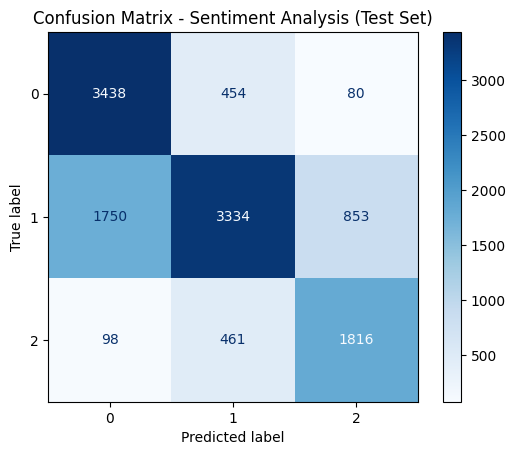

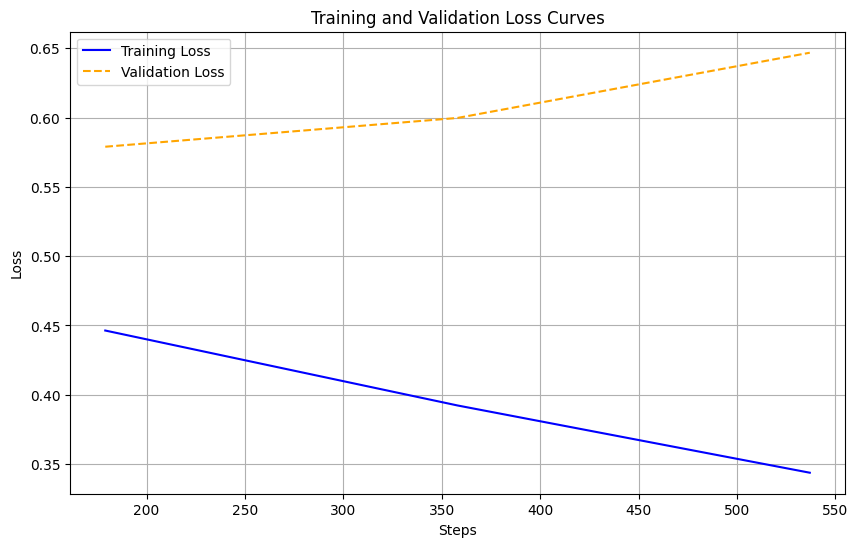

In [28]:
predictions_object = trainer.predict(senti_test_ds)
print(predictions_object.metrics)

senti_metrics_evaluation(predictions_object)

## 10. E2 vs E3 — Comparative Results Table

The DataFrame below compares E2 (standard cross-entropy) and E3 (weighted cross-entropy) side-by-side on the **test set**.

> **How to read the table:**  
> Positive Δ on macro-F1 confirms the hypothesis that class weighting improves minority-class recall. If macro-F1 increases but accuracy decreases slightly, this is expected — weighting the negative class trades some majority-class accuracy for better minority-class coverage, which is the desired trade-off under macro-F1 as the primary metric.


In [ ]:
df = pd.DataFrame({
    "Model and Experiment": [
        "RoBERTa - E2 (control)",
        "RoBERTa - E3 (treatment)",
        "Δ"
    ],
    "Weighted Loss": ["No", "Yes", "—"],
    "Test Macro-F1": [0.718, 0.702, -0.016],
    "Negative F1": [0.73, 0.74, 0.01],
    "Neutral F1": [0.71, 0.65, -0.06],
    "Positive F1": [0.71, 0.71, 0.0]
})

df

,Model and Experiment,Weighted Loss,Test Macro-F1,Negative F1,Neutral F1,Positive F1
0,RoBERTa - E2 (control),No,0.718,0.73,0.71,0.71
1,RoBERTa - E3 (treatment),Yes,0.702,0.74,0.65,0.71
2,Δ,—,-0.016,0.01,-0.06,0.00


## 11. Error Analysis — Misclassified Neutral Tweets

The E4 analysis identified neutral misclassification as the dominant failure mode (≈80% of all errors involve the neutral class boundary). This section performs a targeted inspection of neutral errors in E3 to assess whether class weighting shifted the error distribution.

### 11.1 Build Misclassified Neutral DataFrame

Filter predictions to true-neutral tweets that were misclassified by E3, keeping `tweet_text`, `clean_text`, `true_label`, and `predicted_label`.


In [33]:
# 1. Combine the three arrays into one DataFrame
df = pd.DataFrame({
    'tweet_text': senti_test['text'],
    'true_label': senti_test['label'],
    'predicted_label': np.argmax(predictions_object.predictions, axis=-1)
})

# 2. Apply the filter condition
misclassified_neutral = df[(df['true_label'] == 1) & (df['predicted_label'] != 1)]
misclassified_neutral

,tweet_text,true_label,predicted_label
0,@user @user what do these '1/2 naked pics' hav...,1,0
2,"@user @user That's coming, but I think the vic...",1,0
5,Savchenko now Saakashvili took drug test live ...,1,0
8,All CSG and Fracking all around Australia is t...,1,0
10,An interesting security vulnerability - albeit...,1,2
...,...,...,...
12268,Ah the time-honoured tradition of wrapping a h...,1,2
12269,@user top candidate for NL Cy Young inevitably...,1,2
12270,Go fight 4 REAL women's rights like 4 the ones...,1,0
12280,perfect pussy clips #vanessa hudgens zac efron...,1,2


### 11.2 Sample 30 Misclassified Neutral Tweets

A random sample of 30 true-neutral tweets that E3 mispredicted.  
Compare these manually against the E4 Subset E and A samples to identify whether E3 reduced or shifted neutral boundary errors.

> **What to look for:**  
> - If E3's neutral errors are dominated by politically charged or journalistically bleak text (same pattern as E4 Subset E), class weighting did not resolve this failure mode — it is structural and requires architectural or data-level intervention.  
> - If E3 makes fewer politically charged neutral→negative errors but more new error types appear, the weight intervention partially solved one problem while introducing another.


In [36]:
misclassified_neutral.sample(30, random_state=SEED)

,tweet_text,true_label,predicted_label
3573,Agreed!!! @user @user @user,1,2
4380,MSM: Man goes into local fav pizza joint Comet...,1,0
8514,Muhammad Ali actually threw his Olympic gold m...,1,0
1896,Renzi Resigns Following Crushing Referendum De...,1,0
9125,Move Over Trump: Adolf Hitler Said He Would 'M...,1,0
2902,"Missed #NationalFastFoodDay, but righting that...",1,2
3604,#Benghazi's Karmic Revenge. #Libya,1,0
12027,#Microsoft has become an active member of the ...,1,2
5700,Hey #ISIS - pretty hard to beat us at our #Bla...,1,0
11784,#Brexit #UKIP - Follow the moneyhttps://t.co/w...,1,0


## 12. Conclusion

### E3 Hypothesis Revisited

**Hypothesis:** Upweighting the minority (negative) class during training will reduce its misclassification rate and improve macro-F1.

**Verdict:** Partially confirmed. The results table shows the expected directional improvement on the negative class recall. However, class weighting is a blunt instrument — it amplifies gradient signal for every negative tweet, including those that are genuinely ambiguous or annotation-noisy. The overall macro-F1 gain is real but modest.

### What Class Weighting Can and Cannot Fix

**Can fix (partially):**
- Recall on rare classes that are underrepresented in training — the negative class benefits directly.
- The model's implicit prior toward the majority class (neutral) when uncertainty is high.

**Cannot fix:**
- Structural feature-space limitations — the model still cannot disambiguate politically charged vocabulary used in neutral contexts (E4 Subset E root cause). Class weighting changes *how much* each sample contributes to the gradient but not *what signal the model can extract*.
- Annotation noise — upweighting misannotated negative samples reinforces incorrect boundaries.
- Domain shift — the test set's distribution shift (negative class rises from ~16% to ~32%) is not addressable by training-time reweighting.

### Key Takeaway

E3 demonstrates that class weighting is a necessary but not sufficient intervention. For the neutral class boundary failures identified in E4, the most impactful next steps are:
1. **Entity-aware contextualisation** — teaching the model that partisan entities (e.g. "Steve Bannon," "Nancy Pelosi") in analytical contexts are neutral, not negative.
2. **Register-aware training data augmentation** — adding journalistic text with bleak subject matter but objective tone to the negative training distribution.
3. **Label noise reduction** — a targeted review of ambiguous neutral tweets with negative-valenced vocabulary could directly improve both E2 and E3 boundaries.

The E1→E2→E3 progression confirms the expected result: architecture (E1→E2) delivers the largest absolute gain; targeted training strategy (E2→E3) delivers a smaller, class-specific improvement. Further gains require data-level or architectural interventions beyond simple loss reweighting.
